### Биномиальное распределение

Мы выяснили, что статистика $Q$ имеет биномиальное распределение.

Биномиальное распределение $Binom(n, \mu)$ &mdash; распределение количества успехов в последовательности из $n$ независимых случайных экспериментов, вероятность успеха в каждом из которых равна $\mu$.

Чтобы работать с распределением, можно создать объект-распределение с помощью библиотеки `scipy.stats`.

Предположим идею для стартапа. Предположим, доставка в вашем сервисе стоит 1000 рублей, а курьеру за работу требуется заплатить 500 рублей. Хотим сделать прибыль > 50%.

Делаем эксперимент. Самостоятельно находим $30$ клиентов и доставляем им заказы через курьеров. Оплачивают покупку $19$ из них, остальные отказываются. Нужно понять достаточно ли такого количеста доставок, чтобы доказать успешность бизнеса?

In [2]:
from scipy.stats import binom

In [3]:
binom_h0 = binom(n=30, p=0.5)  # количество испытаний  # вероятность успеха

### Функция вероятности

Функция вероятности дискретного распределения $p_\xi(x)$ &mdash; вероятность, с которой $\xi$ принимает значение $x$.

В Python это функция `pmf` (probability mass function)

In [4]:
binom_h0.pmf(20)

np.float64(0.027981600724160654)

Изобразим распределение статистики $Q$ при справедливости $\mathsf{H}_0$ на графике. Для этого можно передать сразу массив точек, для которых надо рассчитать вероятность.

In [5]:
import numpy

In [6]:
# координата
x_grid = numpy.arange(1, 31)
# для каждой координаты вычисляем вероятность
probs = binom_h0.pmf(x_grid)

In [7]:
from matplotlib import pyplot

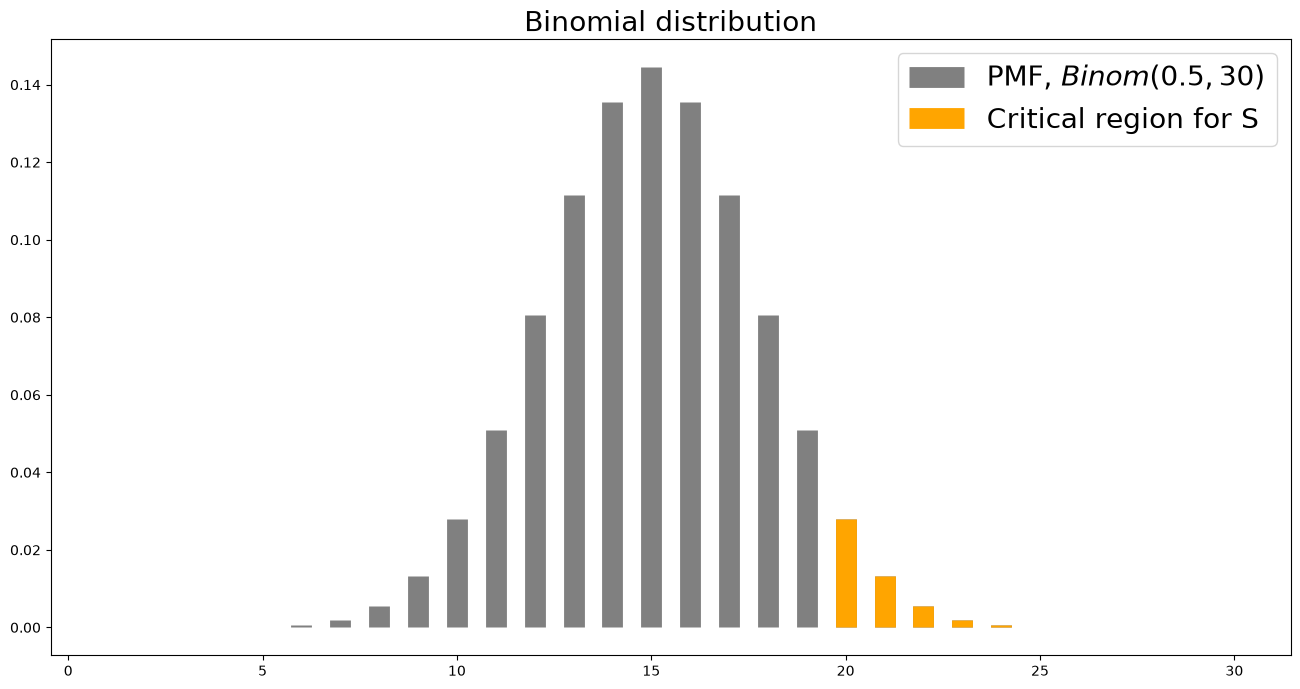

In [18]:
pyplot.figure(figsize=(16, 8))
pyplot.vlines(
    x_grid, 0, probs, linewidth=15.0, color="grey", label="PMF, $Binom(0.5, 30)$"
)
crit_reg = x_grid >= 20
pyplot.vlines(
    x_grid[crit_reg],
    0,
    probs[crit_reg],
    linewidth=15.0,
    color="orange",
    label="Critical region for S",
)
pyplot.title("Binomial distribution", fontsize=20)
pyplot.legend(fontsize=20)
pyplot.show()

На самом деле уже сейчас мы можем посчитать вероятность попадания в критическую область. Нужно просто просуммировать высоты оранжевых столбцов.

In [9]:
numpy.sum(probs[crit_reg])

np.float64(0.04936857335269452)

Попробую взять число 19 и посчитать вероятность попадания в критическую область

In [10]:
crit_reg = x_grid >= 19
numpy.sum(probs[crit_reg])

np.float64(0.10024421103298672)

Тогда вероятность ошибки уже даже больше $10\%$, что совсем нам не подходит. Видно, что нет такого $C$, чтобы False Positive Rate был ровно $5\%$.

### Кумулятивная функция распределения

Кумулятивная функция распределения $F_\xi(x) = P(\xi \leqslant x)$

В Python это функция `cdf` (cumulative distribution function).
Важно, что в питоне считается включительно

In [11]:
alfa = binom_h0.cdf(19)
alfa

np.float64(0.9506314266473055)

По строчке выше понятно, что вероятность получить $19$ или меньше успехов в нашей задаче $\geqslant 0.95$. А поскольку $P(\xi \leqslant 19) + P(\xi \geqslant 20) = 1$, можем вычислить уровень значимости нашего критерия.

In [12]:
1 - alfa

np.float64(0.04936857335269451)

### Квантиль

Чтобы выбрать критическую область для критерия, мы хотели бы найти точку, площадь столбцов справа от которой была бы $5\%$. То есть площадь столбцов слева &mdash; $95\%$. Такая точка называется *квантилью*.

$$ u_p(\xi) = \{x\ | F_\xi(x) = p\} $$

Но при $p = 0.95$ и нашем биномиальном распределении, такой точки нет. Мы выяснили, что есть точка, справа от которой площадь $0.494$, а у следующей уже $0.1$. Чтобы определить квантиль в этом случае, модифицируем определение:

Квантиль $Quantile_p(\xi) = u_p(\xi) = min\ \{x\ |\ F_\xi(x) \geqslant p \}$ &mdash; величина, которую $\xi$ не превышает с вероятностью хотя бы $p$.

**Пример**

Для величины $\xi \sim Bin(30, 0.5)$ посчитаем 0.95-квантиль. Решим задачу просто подбором.

$$ P(\xi \leqslant 18) \approx 0.90$$
$$ P(\xi \leqslant 19) \approx 0.951 $$
$$ P(\xi \leqslant 20) \approx 0.97 $$

Видим, что 18 нам ещё не подходит, а 19 и большие значение уже подойдут. В них функция распределения будет больше $p$. Ответ - наименьшее подходящее значение, то есть 19. При этом нет точки, где функция распределения была бы равна $p$ в точности.


Если бы распределение было непрерывное, можно было бы сказать, что квантиль &mdash; такое $x$, на котором функция распределения равна $p$. Но в прошлом пункте увидели, что для дискретного распределения такого может не быть.

В Python квантиль можно посчитать через функцию `ppf` (percent point function)


In [13]:
binom_h0.ppf(0.95)

np.float64(19.0)

Как теперь подобрать $C$ (критическое значение) для любых $n, \mu$ и для любого уровня значимости $\alpha$?

1. Требуется найти $C$, такое что $P(Q \geqslant C) \leqslant \alpha$
2. То есть требуется $P(Q < C) \geqslant 1 - \alpha$
3. Q принимает только целые значения: $P(Q \leqslant C - 1) \geqslant 1 - \alpha$, или $F(C - 1) \geqslant 1 - \alpha$
4. Значит, из определения квантили, $C - 1 = u_{1 - \alpha}$
5. Значит $C = u_{1 - \alpha} + 1$

In [20]:
def make_binom_criterion(n, mu=0.5, alpha=0.05):
    """Строит критерий для задачи с доставкой

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C для критерия S = {Q >= C}
    """
    binom_h0 = binom(n, mu)
    q = binom_h0.ppf(1 - alpha)
    return q + 1

Применим к нашей постановке

In [21]:
C = make_binom_criterion(n=30, mu=0.5, alpha=0.05)
print(f"if Q>={C} then reject H0 else accept H0")

if Q>=20.0 then reject H0 else accept H0


### Более экстремальные значения

Предположим, мы провели эксперимент и посчитали для критерия его статистику $Q(\xi)$. Обозначим полученное значение $q$, в текущей задаче это $q = 19$. Если бы количество успешных доставок было ещё больше, это бы сильнее свидетельствовало о том, что гипотеза $\mathsf{H}_0$ не выполнена. То есть в случае значения $25$ мы были бы ещё сильнее уверены в том, что наш бизнес будет окупаться. Тогда значение $25$ называется *более экстремальным*, чем значение $19$. В нашей задаче более экстремально из двух значений то, которое больше.

Определим понятие экстремальности формально:

$$ S = \{Q(\xi) \geqslant C\}:\ t\ \text{экстремальнее}\ q \Leftrightarrow t > q $$

Зачастую критерии других видов можно привести к этому, тогда для них тоже определено понятие экстремальности.

### p-value

**p-value** &mdash; это вероятность при справедливости $\mathsf{H}_0$ получить столь же экстремальное значение статистики $q$ или ещё более экстремальное.

$$ P_{\mathsf{H}_0}(Q \geqslant q) $$

In [16]:
C = 20 # критическое значение
qs = [10, 19, 20, 23]  # разные реализации статистики

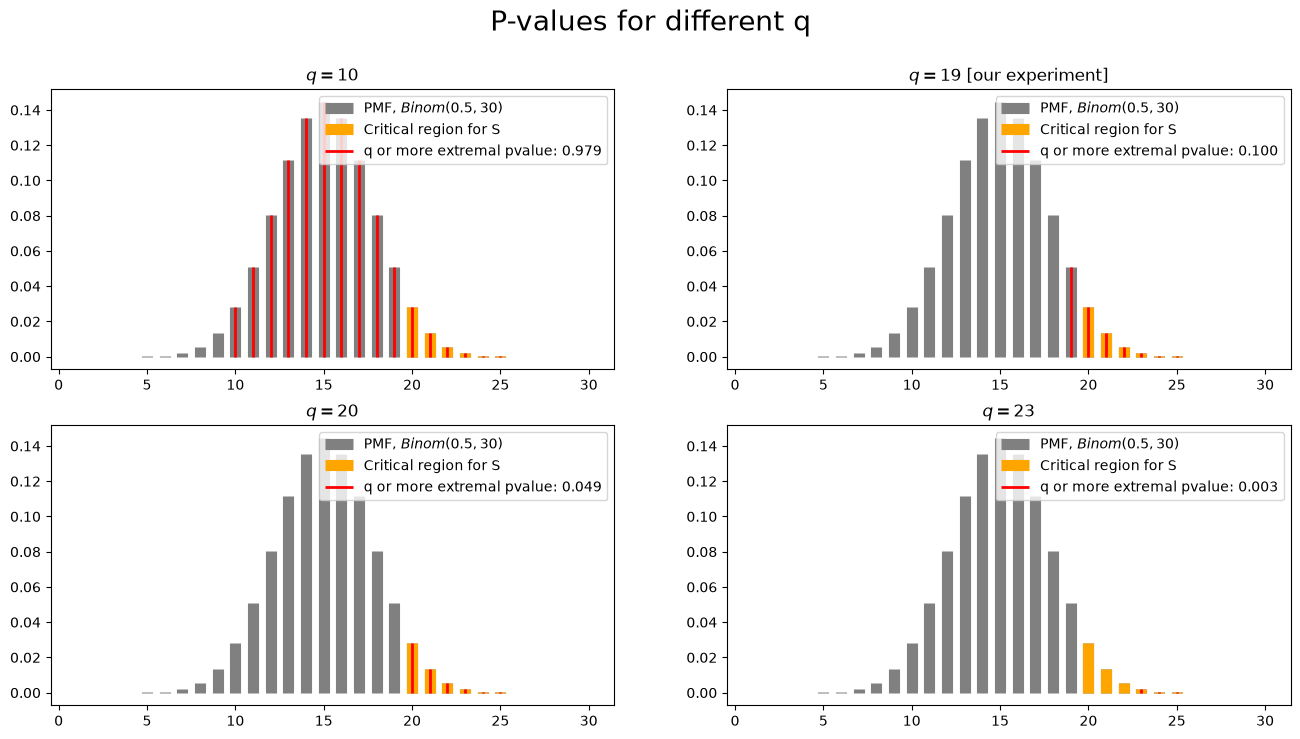

In [19]:
fig, axes = pyplot.subplots(2, 2, figsize=(16, 8))
for q, ax in zip(qs, axes.flatten()):
    ax.set_title(f'$q = {q}$' + (' [our experiment]' if q == 19 else ''))
    ax.vlines(x_grid, 0, probs, linewidth=8, color='grey', label='PMF, $Binom(0.5, 30)$')
    crit_reg = x_grid >= C
    ax.vlines(x_grid[crit_reg], 0, probs[crit_reg], linewidth=8, color='orange', label='Critical region for S')
    pvalue = 1 - binom_h0.cdf(q-1)
    more_extremal = x_grid >= q
    ax.vlines(x_grid[more_extremal], 0, probs[more_extremal], linewidth=2, color='red', label=f'q or more extremal pvalue: {pvalue:.3f}')
    ax.legend()

pyplot.suptitle('P-values for different q', fontsize=20)
pyplot.show()

Можно увидеть, что в критической области $p-value \leqslant \alpha$, а вне её $p-value > \alpha$. Именно такое правило и используется для принятия решения

$$ \mathsf{H}_0 \text{ отвергается } \Leftrightarrow p-value \leqslant \alpha $$

Причём по p-value сразу видно, что если бы в нашу критическую области включили значение $19$, наш критерий допускал бы False Positive в $10\%$ случаев, что уже недопустимо. Поэтому и гипотезу мы не отвергаем.

Заметим, что для вычисления p-value не понадобилось знание $\alpha$, а нужна была только статистика и форма критерия.

## Двусторонные критерии

Пусть вам дали монетку и просят проверить, честная она или нет. Монетка честная, если при подбрасываниях вероятность выпадения орла равна $0.5$. Вы подбрасываете монетку $30$ раз, каждый бросок &mdash; бернуллиевская величина, аналогично задаче с доставками. И нулевая гипотеза та же самая: $\mu = 0.5$. Но теперь мы хотим отвергать эту  гипотезу как в случае большой вероятности орла, так и в случае маленькой, соответственно проверяем *двустороннюю гипотезу*.

$$ \mathsf{H}_0: \mu = 0.5 $$
$$ \mathsf{H}_1: \mu \neq 0.5 $$

Выберем критическую область для критерия при такой альтернативе. Воспользуемся той же статистикой $Q(\xi) = \sum \xi_i$. Только теперь отклонения в каждую сторону одинаково важны. Отвергать гипотезу будем не только на достаточно больших значениях, но и на достаточно маленьких. Например, если у нас было всего $2$ орла из $30$ &mdash; это свидетельство в пользу того, что $\mu \neq 0.5$, но не в пользу $\mu > 0.5$.

Поскольку отклонения в разные стороны одинаково важны, а распределение симметричное, искать критерий можно в таком виде:

$$ S = \{|Q(\xi) - 15| \geqslant C\} $$

### Как выбрать критическую область

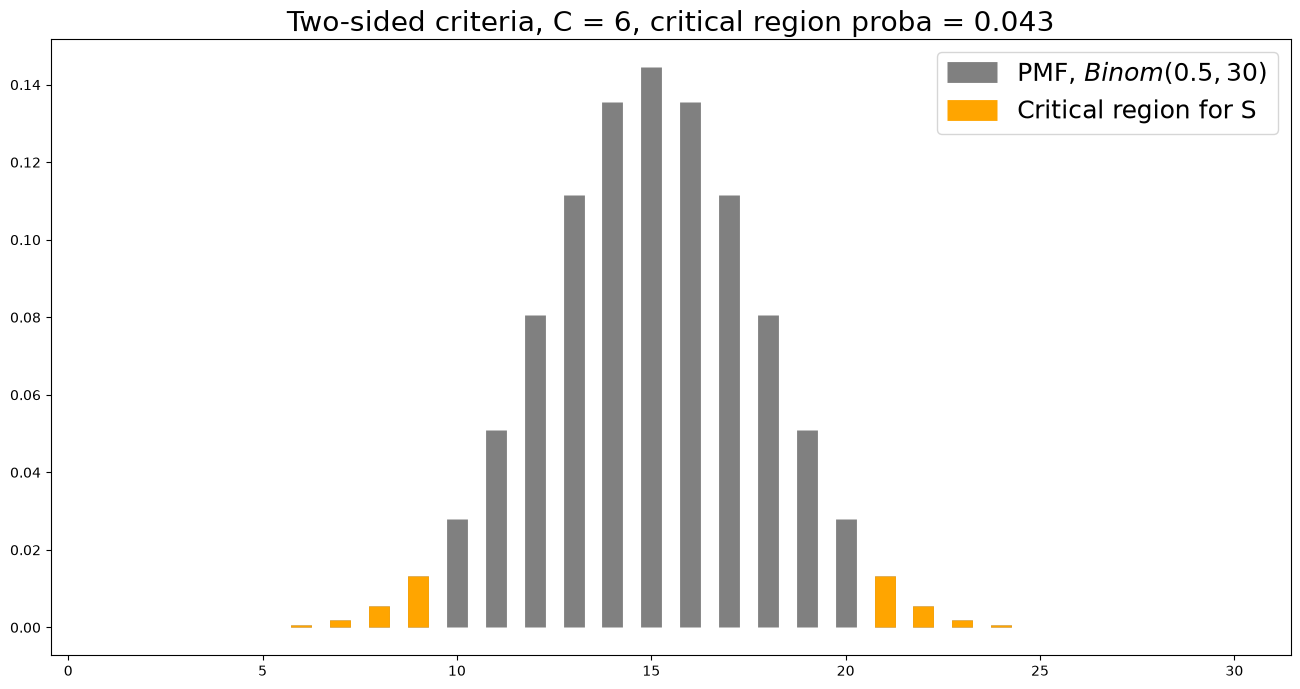

In [ ]:
C = 6
pyplot.figure(figsize=(16, 8))
pyplot.vlines(x_grid, 0, probs, linewidth=15, color='grey', label='PMF, $Binom(0.5, 30)$')
crit_reg = numpy.abs(x_grid-15) >= C
pyplot.vlines(x_grid[crit_reg], 0, probs[crit_reg], linewidth=15, color='orange', label='Critical region for S')
rejection_prob = probs[crit_reg].sum()
pyplot.title(f'Two-sided criteria, C = {C}, critical region proba = {rejection_prob:.3f}', fontsize=20)
pyplot.legend(fontsize=18)
pyplot.show()

По картинке видно, что если теперь отвергать отклонения при $Q \geqslant 20$, то необходимо отвергать и $Q \leqslant 10$, а значит общая площадь столбцов будет уже примерно $0.1$. Поэтому при уровне значимости $0.05$ и $20$ успехах гипотеза уже не отвергнется.

Если же выставить $C = 6$, то такая область уже подходит, площадь столбцов $\approx 0.043 < 0.05$

Чтобы выбрать пороговую константу по формуле, можно заметить, что критическая область симметрична, а значит справа площадь не должна быть больше, чем $\frac{\alpha}{2}$. А такую задачу мы уже умеем решать. Реализуем функцию на Python.

In [52]:
def make_binom_criterion_two_sided(n, alpha=0.05):
    '''Строит критерий для задачи с доставкой для mu = 0.5 и двусторонней альтернативы

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C для критерия S = {|Q - 15| >= C}
    '''
    right_crit_value = make_binom_criterion(n=n, alpha=alpha/2)
    diff = right_crit_value-15
    return diff

In [53]:
make_binom_criterion_two_sided(30)

np.float64(6.0)

### Как считать p-value

Критерий имеет вид

$$ S = \{|Q(\xi) - 15| \geqslant C\} $$

Обозначим отклонение суммы от 15 как $ \Delta(\xi) =  |Q(\xi) - 15| $, тогда мы имеем критерий

$$ S = \{\Delta(\xi) \geqslant C\} $$

То есть более экстремальными будут считаться те значения суммы, которые находятся дальше от 15. Чтобы вычислить p-value, придётся посчитать сумму площадей с двух сторон по-отдельности.

In [55]:
def pvalue_two_sided_sym(n, q):
    '''Считает pvalue для задачи с доставкой для mu = 0.5 и двусторонней альтернативы

    Параметры:
        n: количество доставок в эксперименте
        q: количество успешных доставок

    Возвращает:
        pvalue для критерия S = {|Q - 15| >= C}
    '''
    binom_h0 = binom(n, 0.5)
    diff = numpy.abs(q - 15)
    left_sq = binom_h0.cdf(15-diff)
    right_sq = 1 - binom_h0.cdf(15+diff-1)
    return left_sq + right_sq


In [58]:
pvalue_two_sided_sym(30, 21)

np.float64(0.04277394525706769)

На самом деле в силу симметричности распределения левая и правая площадь получаются одинаковыми, поэтому можно посчитать площадь с одной стороны и умножить на 2.

In [ ]:
def pvalue_two_sided_sym_simple(n, q):
    '''Считает pvalue для задачи с доставкой для mu = 0.5 и двусторонней альтернативы

    Параметры:
        n: количество доставок в эксперименте
        q: количество успешных доставок

    Возвращает:
        pvalue для критерия S = {|Q - 15| >= C}
    '''
    binom_h0 = binom(n, 0.5)
    left_sq = binom_h0.cdf(q)
    right_sq = 1 - binom_h0.cdf(q-1)
    return 2*min(left_sq, right_sq, 0.5)

    # binom_h0 = binom(n, 0.5)
    # diff = numpy.abs(q - 15)
    # left_sq = binom_h0.cdf(15-diff)
    # right_sq = 1 - binom_h0.cdf(15+diff-1)
    # return min(left_sq + right_sq, 1.0)

In [79]:
pvalue_two_sided_sym_simple(30, 21)

np.float64(0.04277394525706769)

Теперь даже в случае $20$ орлов $pvalue > 0.05$, поэтому отвергать будем значения, начиная с $21$ и меньше либо равные $9$.

### Случай с несимметричным распределением

Когда распределение при справедливости $\mathsf{H}_0$ несимметрично, отклонения от ожидаемого значения в разные стороны могут быть по-разному критичны. В качестве примера рассмотрим также биномиальное распределение, но с вероятностью успеха $0.8$. 

Тогда можно левую и правую критические области построить отдельно, выделив на них по $\frac{\alpha}{2}$ площади. Правую область мы уже умеем искать, найдём левую.

In [92]:
binom_h0_nonsym = binom(
    n=30, # количество испытаний
    p=0.8 # вероятность успеха
)
probs_nonsym = binom_h0_nonsym.pmf(x_grid)

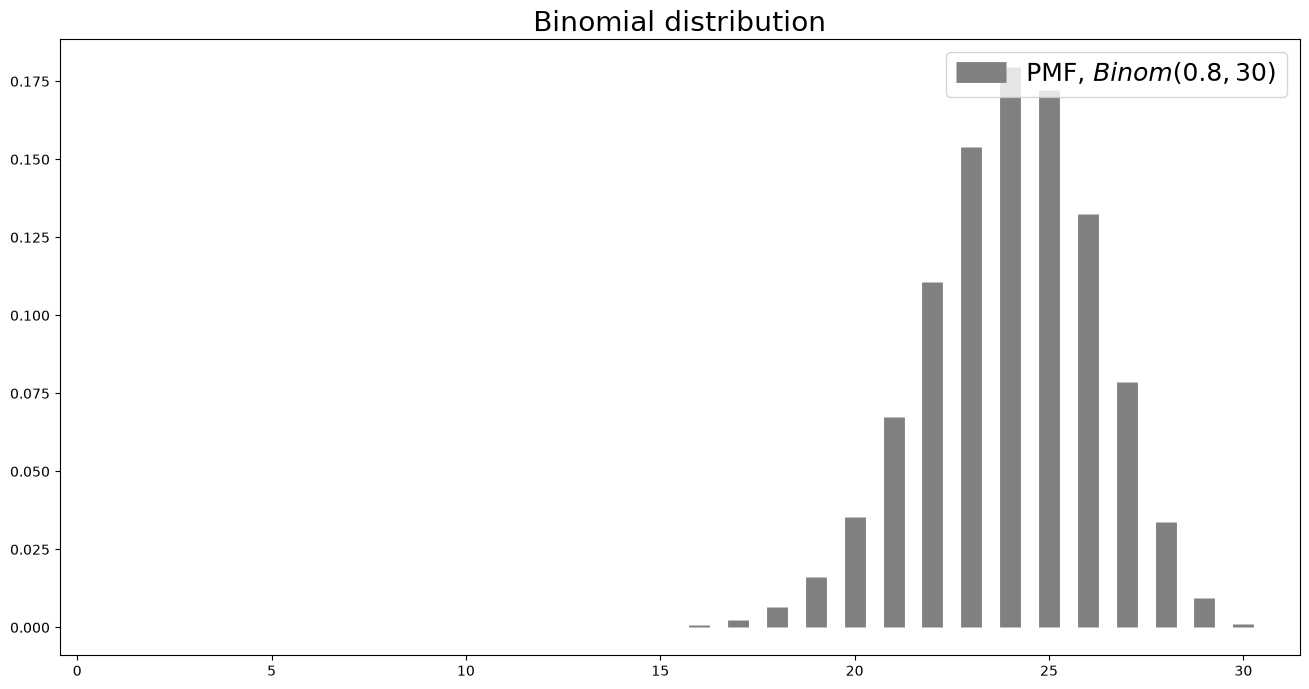

In [93]:
pyplot.figure(figsize=(16, 8))
pyplot.vlines(x_grid, 0, probs_nonsym, linewidth=15.0, color='grey', label='PMF, $Binom(0.8, 30)$')
pyplot.title('Binomial distribution', fontsize=20)
pyplot.legend(fontsize=18)
pyplot.show()

Для того, чтобы построить двусторонний критерий, нужно найти слева и справа области, площадь которых составляет не больше, чем $\frac{\alpha}{2}$. Для правой стороны мы уже решали такую задачу, решим для левой.

Ищем $C$, такое что

$$ P(Q(\xi) \leqslant C) \leqslant \frac{\alpha}{2} $$

Сначала найдём первое число, где вероятность $\geqslant \frac{\alpha}{2}$. А это по определению $\frac{\alpha}{2}$-квантиль. Достаточно взять предыдущее число, и оно будет удовлетворять нашему условию.

In [97]:
def two_sided_criterion_nonsym(n, mu, alpha):
    '''Строит двусторонний критерий для несимметричной задачи с доставкой

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C1, C2 для критерия S = {Q <= C1 или Q >= C2}
    '''
    binom_h0 = binom(n, mu)
    C1 = binom_h0.ppf(alpha/2)-1
    C2 = binom_h0.ppf(1 - alpha/2)+1
    return C1, C2


In [98]:
c1, c2 = two_sided_criterion_nonsym(30, 0.8, 0.05)

In [99]:
c1, c2

(np.float64(18.0), np.float64(29.0))

Значит наш критерий для проверки гипотезы

$$ \mathsf{H}_0: \mu = 0.8 $$
$$ \mathsf{H}_1: \mu \neq 0.8 $$

имеет вид

$$ S = \{Q(\xi) \leqslant 18\} \cup \{Q(\xi) \geqslant 29\}$$

Здесь граница $29$ уже выглядит логично, потому что надо опровергнуть 80% орлов/успехов, а для этого требуется большое их количество.

Изобразим критическую область на графике.

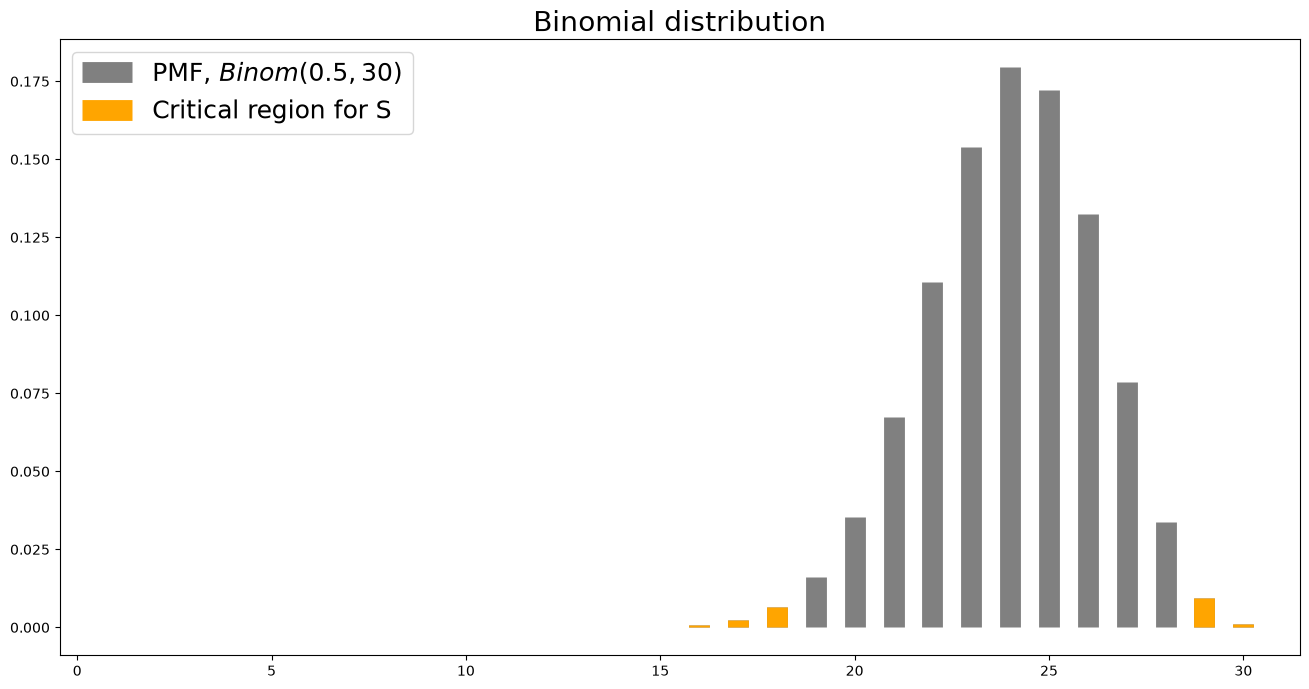

In [103]:
pyplot.figure(figsize=(16, 8))
pyplot.vlines(x_grid, 0, probs_nonsym, linewidth=15.0, color='grey', label='PMF, $Binom(0.5, 30)$')
crit_reg = (x_grid <= c1) | (x_grid >= c2)
pyplot.vlines(x_grid[crit_reg], 0, probs_nonsym[crit_reg], linewidth=15.0, color='orange', label='Critical region for S')
pyplot.title('Binomial distribution', fontsize=20)
pyplot.legend(fontsize=18, loc='upper left')
pyplot.show()

### p-value для несимметричного распределения

Этот критерий &mdash; объединение двух критериев уровня значимости $\frac{\alpha}{2}$, для каждого из которых можно посчитать p-value. Обозначим их как $p_1, p_2$. Первый критерий отвергается при $p_1 \leqslant \frac{\alpha}{2}$, второй при $p_2 \leqslant \frac{\alpha}{2}$. А наш объединённый, когда выполнено одно из этих условий, то есть

$$ 2p_1 \leqslant \alpha \vee 2p_2 \leqslant \alpha \Leftrightarrow 2 \cdot \min(p_1, p_2) \leqslant \alpha $$

Значит можно считать pvalue как $2  \min(p_1, p_2, 0.5)$ и сравнивать с $\alpha$.

Проведём аналогию с симметричным случаем: если сумма оказалась в левой части, то нужно посчитать p-value левого критерия и умножить на 2. Если сумма оказалась в правой части, то нужно посчитать p-value правого критерия и умножить на 2.

In [109]:
def pvalue_two_sided(n, q, mu=0.5):
    '''Считает pvalue для двусторонней альтернативы в задаче с доставкой

    Параметры:
        n: количество доставок в эксперименте
        q: количество успешных доставок
        mu: вероятность успеха при H0

    Возвращает:
        pvalue для двустороннего критерия
    '''
    binom_h0 = binom(n, mu)
    left_sq = binom_h0.cdf(q)
    right_sq = 1 - binom_h0.cdf(q-1)
    return 2 * min(left_sq, right_sq, 0.5)

In [114]:
pvalue_two_sided(n=30, q=19, mu=0.8)

np.float64(0.05123251067065303)